# EDA (Exploratory Data Analysis)

- Sayısal verilerin dağılımını analiz ediyorum

In [ ]:
%pip install -U matplotlib
%pip install -U seaborn

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt 
import seaborn as sb 
df = pd.read_csv(r"data\heart.csv")
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


## Histogram Analizi

<module 'matplotlib.pyplot' from 'c:\\Users\\amate\\Desktop\\Uni\\Projeler\\kalp-krizi-risk-tahmini\\.env\\Lib\\site-packages\\matplotlib\\pyplot.py'>

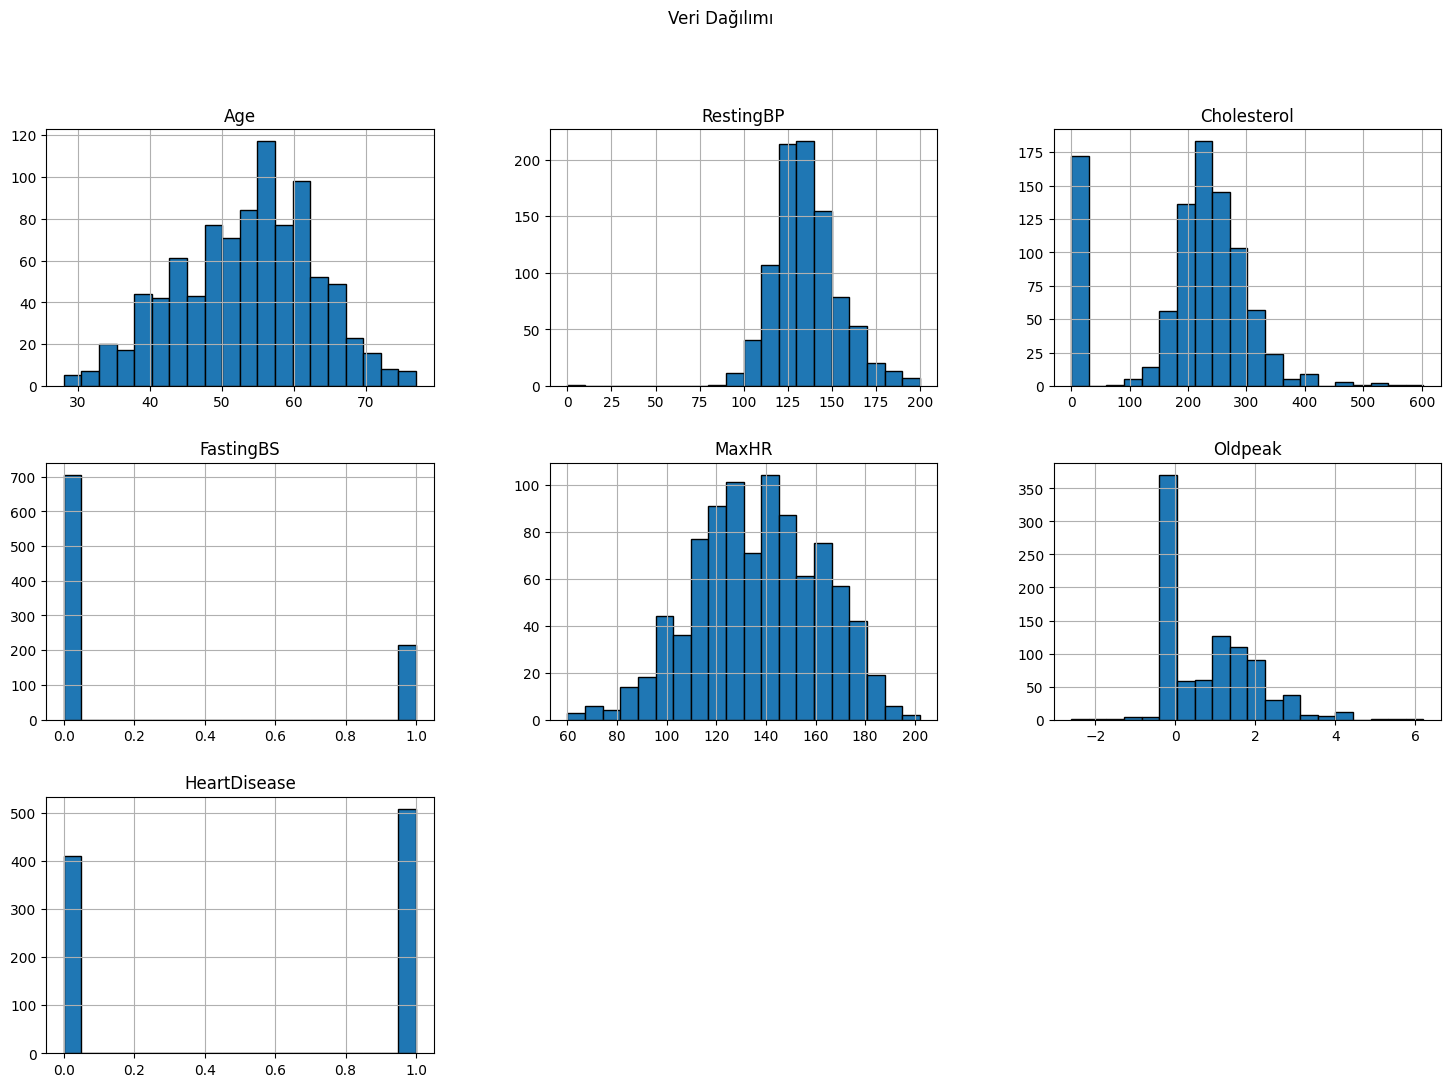

In [3]:
df.hist(figsize=(18,12),bins = 20, edgecolor = "black")
plt.suptitle("Veri Dağılımı")
plt

## Scatter Plot (Saçılım Grafiği) Analizi

<module 'matplotlib.pyplot' from 'c:\\Users\\amate\\Desktop\\Uni\\Projeler\\kalp-krizi-risk-tahmini\\.env\\Lib\\site-packages\\matplotlib\\pyplot.py'>

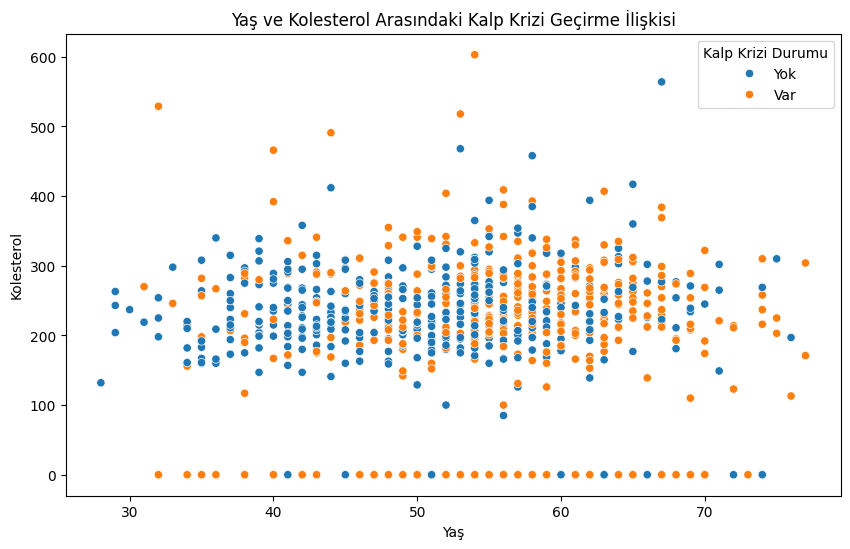

In [4]:
plt.figure(figsize=(10,6))
sb.scatterplot(data=df, x='Age',y='Cholesterol',hue=df['HeartDisease'].map({0: 'Yok', 1: 'Var'}))
plt.legend(title='Kalp Krizi Durumu' )
plt.title('Yaş ve Kolesterol Arasındaki Kalp Krizi Geçirme İlişkisi')
plt.xlabel('Yaş')
plt.ylabel('Kolesterol')
plt

### Sadece Kalp Krizi Geçirme Durumu Olanları Görüntüleme

<module 'matplotlib.pyplot' from 'c:\\Users\\amate\\Desktop\\Uni\\Projeler\\kalp-krizi-risk-tahmini\\.env\\Lib\\site-packages\\matplotlib\\pyplot.py'>

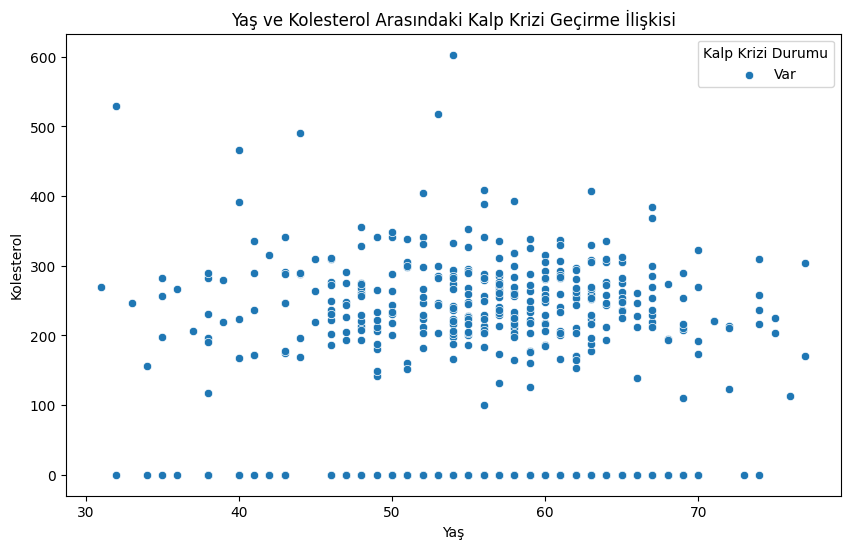

In [5]:
plt.figure(figsize=(10,6))
sb.scatterplot(data=df[df['HeartDisease'] == 1], x='Age', y='Cholesterol', label='Var') 
plt.title('Yaş ve Kolesterol Arasındaki Kalp Krizi Geçirme İlişkisi')
plt.legend(title='Kalp Krizi Durumu')
plt.xlabel('Yaş')
plt.ylabel('Kolesterol')
plt

## Korelasyon Isı Haritası (Correlation Heatmap) Analizi
Korelasyon Matrisi Çizimi
- **df_numeric.corr()** = Veri setindeki tüm sayısal sütunlar arasındaki Pearson korelasyon katsayılarını hesaplar. Sonuç -1 ile +1 arasında bir matristir
- **annot=True** = Her hücrenin üzerine korelasyon değerini sayı olarak yazar. Kapatılırsa sadece renkler görünür, sayılar görünmez
- **cmap='coolwarm'** = Renk paletini belirler. coolwarm'da mavi → negatif korelasyon, beyaz → sıfır, kırmızı → pozitif korelasyon anlamına gelir
- **fmt='.2f'** = Hücrelerdeki sayıların formatını belirler: virgülden sonra 2 basamak göster (ör. 0.49, -0.56)

<module 'matplotlib.pyplot' from 'c:\\Users\\amate\\Desktop\\Uni\\Projeler\\kalp-krizi-risk-tahmini\\.env\\Lib\\site-packages\\matplotlib\\pyplot.py'>

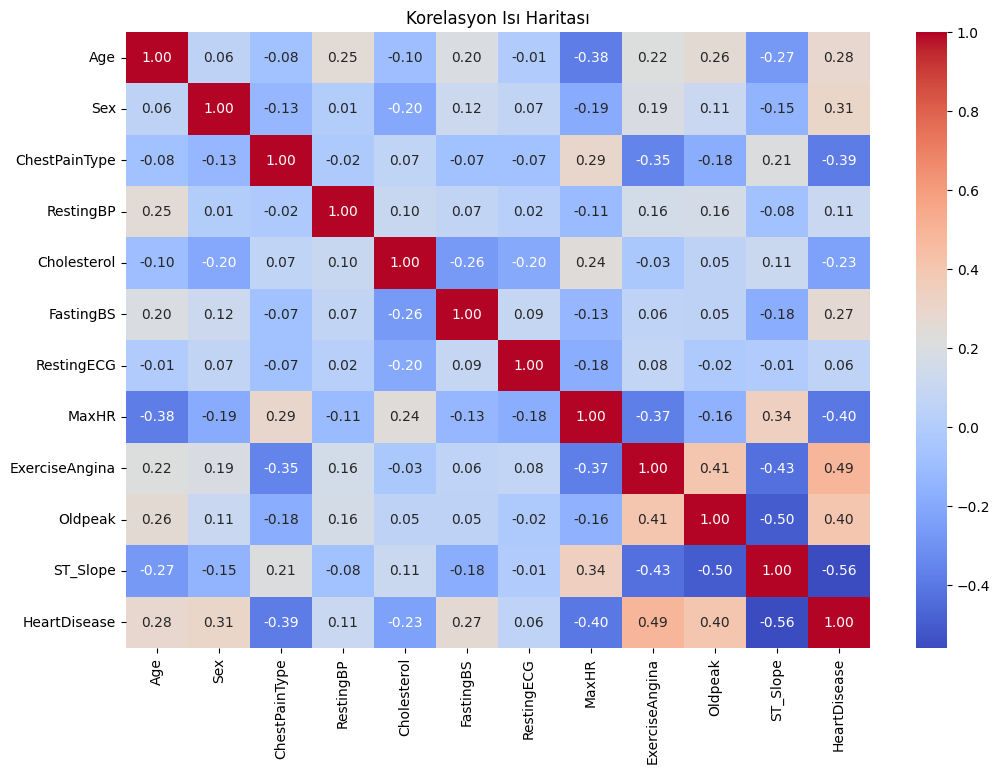

In [6]:
df_numeric = pd.read_csv(r"data\heart_processed.csv")
plt.figure(figsize=(12,8))
sb.heatmap(df_numeric.corr(), annot= True, cmap= 'coolwarm', fmt='.2f')
plt.title('Korelasyon Isı Haritası')
plt

| Değer | Anlam |
|-------|-------|
| +1.00'e yakın | Güçlü pozitif ilişki (biri artınca diğeri artar) |
| 0'a yakın | İlişki yok |
| -1.00'e yakın | Güçlü negatif ilişki (biri artınca diğeri azalır) |

**Bu haritadan öne çıkan bulgular:**

- **ST_Slope ↔ HeartDisease: -0.56** → ST eğimi arttıkça kalp hastalığı riski belirgin şekilde düşüyor (en güçlü negatif ilişki).
- **ExerciseAngina ↔ HeartDisease: +0.49** → Egzersiz anjini olanların kalp hastalığı taşıma ihtimali yüksek.
- **Oldpeak ↔ HeartDisease: +0.40** → Oldpeak değeri yükseldikçe hastalık riski artıyor.
- **MaxHR ↔ HeartDisease: -0.40** → Maksimum kalp hızı yüksek olanlar daha az hasta.

## Tek Değişkenli Analiz

<module 'matplotlib.pyplot' from 'c:\\Users\\amate\\Desktop\\Uni\\Projeler\\kalp-krizi-risk-tahmini\\.env\\Lib\\site-packages\\matplotlib\\pyplot.py'>

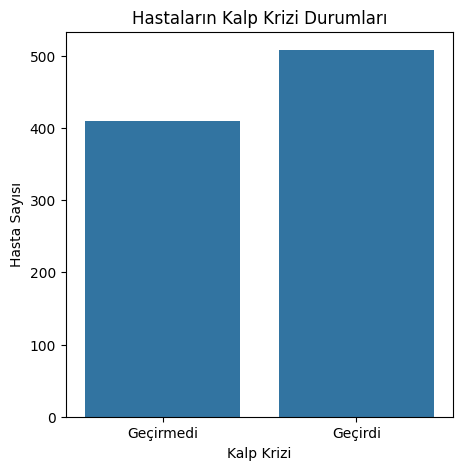

In [7]:
plt.figure(figsize=(5,5))
sb.countplot(data=df,x='HeartDisease')
plt.title("Hastaların Kalp Krizi Durumları")
plt.xlabel("Kalp Krizi")
plt.ylabel("Hasta Sayısı")
plt.xticks(ticks=[0, 1], labels=['Geçirmedi', 'Geçirdi'])
plt